In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"]     = 100
sns.set_theme(style="darkgrid")

os.makedirs("bluestock/reports/charts", exist_ok=True)
os.makedirs("bluestock/data/processed", exist_ok=True)

print(" Libraries imported")

 Libraries imported


In [3]:
PROC = "bluestock/data/processed"

df_nav   = pd.read_csv(f"{PROC}/02_nav_history_clean.csv",  parse_dates=["date"])
df_fund  = pd.read_csv(f"{PROC}/01_fund_master_clean.csv")
df_bm    = pd.read_csv(f"{PROC}/10_benchmark_clean.csv",    parse_dates=["date"])
df_perf  = pd.read_csv(f"{PROC}/07_performance_clean.csv")

print("Data loaded")
print(f"   NAV records  : {len(df_nav):,}")
print(f"   Schemes      : {df_nav['amfi_code'].nunique()}")
print(f"   Benchmarks   : {df_bm['index_name'].unique()}")

Data loaded
   NAV records  : 46,000
   Schemes      : 40
   Benchmarks   : ['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']


In [4]:
# ── Daily Returns ─────────────────────────────────────────
df_nav = df_nav.sort_values(["amfi_code","date"])
df_nav["daily_return"] = df_nav.groupby("amfi_code")["nav"].pct_change()

# ── CAGR Function ─────────────────────────────────────────
def compute_cagr(nav_series, years):
    """CAGR = (NAV_end / NAV_start) ^ (1/years) - 1"""
    if len(nav_series) < 2:
        return np.nan
    return (nav_series.iloc[-1] / nav_series.iloc[0]) ** (1/years) - 1

# ── Compute CAGR per scheme ───────────────────────────────
cagr_rows = []
for code, grp in df_nav.groupby("amfi_code"):
    grp = grp.sort_values("date")
    end_date = grp["date"].max()

    def nav_for_years(y):
        start = end_date - pd.DateOffset(years=y)
        sub   = grp[grp["date"] >= start]
        return compute_cagr(sub["nav"], y) * 100 if len(sub) > 10 else np.nan

    cagr_rows.append({
        "amfi_code"  : code,
        "cagr_1y_pct": round(nav_for_years(1), 2),
        "cagr_3y_pct": round(nav_for_years(3), 2),
        "cagr_5y_pct": round(nav_for_years(4) if nav_for_years(5) is np.nan
                             else nav_for_years(5), 2),
    })

df_cagr = pd.DataFrame(cagr_rows)
df_cagr = df_cagr.merge(df_fund[["amfi_code","scheme_name","fund_house",
                                   "category","sub_category"]], on="amfi_code")
df_cagr.to_csv(f"{PROC}/returns_computed.csv", index=False)

print("CAGR computed")
print(df_cagr[["scheme_name","cagr_1y_pct","cagr_3y_pct","cagr_5y_pct"]].head(5).to_string(index=False))

CAGR computed
                                       scheme_name  cagr_1y_pct  cagr_3y_pct  cagr_5y_pct
         HDFC Top 100 Fund - Regular Plan - Growth        -2.22         1.29         2.32
      HDFC Short Term Debt Fund - Regular - Growth         3.70         3.92         3.91
HDFC Mid-Cap Opportunities Fund - Regular - Growth        53.23        32.44        26.07
     ABSL Frontline Equity Fund - Regular - Growth        47.92        28.97        20.44
            ABSL Small Cap Fund - Regular - Growth       -23.99        -4.15         6.95


In [5]:
RISK_FREE = 0.065 / 252   # RBI repo rate 6.5% daily

sharpe_rows = []

for code, grp in df_nav.groupby("amfi_code"):
    grp     = grp.sort_values("date").dropna(subset=["daily_return"])
    returns = grp["daily_return"]

    if len(returns) < 50:
        continue

    # ── Sharpe ────────────────────────────────────────────
    excess   = returns - RISK_FREE
    sharpe   = (excess.mean() / returns.std()) * np.sqrt(252)

    # ── Sortino ───────────────────────────────────────────
    downside = returns[returns < 0].std()
    sortino  = (excess.mean() / downside) * np.sqrt(252) if downside > 0 else np.nan

    # ── Annualised Return ─────────────────────────────────
    ann_ret  = ((1 + returns.mean()) ** 252 - 1) * 100

    # ── Annualised Std Dev ────────────────────────────────
    ann_std  = returns.std() * np.sqrt(252) * 100

    sharpe_rows.append({
        "amfi_code"    : code,
        "ann_return_pct": round(ann_ret,  3),
        "ann_std_pct"  : round(ann_std,   3),
        "sharpe_ratio" : round(sharpe,    3),
        "sortino_ratio": round(sortino,   3),
    })

df_sharpe = pd.DataFrame(sharpe_rows)
df_sharpe = df_sharpe.merge(
    df_fund[["amfi_code","scheme_name","fund_house"]], on="amfi_code")
df_sharpe.to_csv(f"{PROC}/sharpe_sortino.csv", index=False)

print("Sharpe & Sortino computed")
print(df_sharpe[["scheme_name","sharpe_ratio","sortino_ratio"]]\
      .sort_values("sharpe_ratio", ascending=False).head(5).to_string(index=False))

Sharpe & Sortino computed
                                  scheme_name  sharpe_ratio  sortino_ratio
Mirae Asset Large Cap Fund - Regular - Growth         1.448          2.386
       Kotak Flexicap Fund - Regular - Growth         1.307          2.364
Mirae Asset Tax Saver Fund - Regular - Growth         1.235          2.147
    SBI Bluechip Fund - Regular Plan - Growth         1.208          2.140
     ICICI Pru Midcap Fund - Regular - Growth         1.180          2.029


In [6]:
# Get Nifty 100 returns
nifty100 = df_bm[df_bm["index_name"] == "NIFTY100"].sort_values("date").copy()
nifty100["bm_return"] = nifty100["close_value"].pct_change()
nifty100 = nifty100[["date","bm_return"]].dropna()

alpha_rows = []

for code, grp in df_nav.groupby("amfi_code"):
    grp = grp.sort_values("date").dropna(subset=["daily_return"])

    # Merge with benchmark
    merged = grp[["date","daily_return"]].merge(nifty100, on="date", how="inner")
    if len(merged) < 50:
        continue

    # OLS Regression
    slope, intercept, r_val, p_val, _ = stats.linregress(
        merged["bm_return"], merged["daily_return"]
    )

    beta    = round(slope, 4)
    alpha   = round(intercept * 252 * 100, 4)   # annualised %
    r_sq    = round(r_val**2, 4)

    alpha_rows.append({
        "amfi_code": code,
        "beta"     : beta,
        "alpha_pct": alpha,
        "r_squared": r_sq,
    })

df_alpha = pd.DataFrame(alpha_rows)
df_alpha = df_alpha.merge(
    df_fund[["amfi_code","scheme_name","fund_house","sub_category"]], on="amfi_code")
df_alpha.to_csv(f"{PROC}/alpha_beta.csv", index=False)

print("Alpha & Beta computed")
print(df_alpha[["scheme_name","alpha_pct","beta","r_squared"]]\
      .sort_values("alpha_pct", ascending=False).head(5).to_string(index=False))

Alpha & Beta computed
                                  scheme_name  alpha_pct    beta  r_squared
   SBI Small Cap Fund - Regular Plan - Growth    30.3370 -0.0232     0.0001
        DSP Small Cap Fund - Regular - Growth    30.0579  0.0115     0.0000
     ICICI Pru Midcap Fund - Regular - Growth    29.2636  0.0005     0.0000
Mirae Asset Tax Saver Fund - Regular - Growth    28.2704  0.0181     0.0002
       Kotak Flexicap Fund - Regular - Growth    27.3305 -0.0228     0.0003


In [7]:
drawdown_rows = []

for code, grp in df_nav.groupby("amfi_code"):
    grp        = grp.sort_values("date")
    nav_series = grp["nav"]

    # Running max
    running_max = nav_series.cummax()
    drawdown    = (nav_series - running_max) / running_max * 100
    max_dd      = drawdown.min()

    # Worst drawdown period
    end_idx   = drawdown.idxmin()
    start_idx = nav_series[:end_idx].idxmax()

    drawdown_rows.append({
        "amfi_code"        : code,
        "max_drawdown_pct" : round(max_dd, 2),
        "drawdown_start"   : grp.loc[start_idx, "date"],
        "drawdown_end"     : grp.loc[end_idx,   "date"],
    })

df_dd = pd.DataFrame(drawdown_rows)
df_dd = df_dd.merge(
    df_fund[["amfi_code","scheme_name","fund_house"]], on="amfi_code")
df_dd.to_csv(f"{PROC}/max_drawdown.csv", index=False)

print(" Max Drawdown computed")
print(df_dd[["scheme_name","max_drawdown_pct","drawdown_start","drawdown_end"]]\
      .sort_values("max_drawdown_pct").head(5).to_string(index=False))

 Max Drawdown computed
                               scheme_name  max_drawdown_pct drawdown_start drawdown_end
 SBI Small Cap Fund - Direct Plan - Growth            -52.57     2023-01-17   2025-10-28
    Axis Small Cap Fund - Regular - Growth            -51.68     2025-05-22   2026-05-11
    ABSL Small Cap Fund - Regular - Growth            -35.45     2024-11-21   2026-05-11
     DSP Small Cap Fund - Regular - Growth            -31.17     2026-04-24   2025-01-03
SBI Small Cap Fund - Regular Plan - Growth            -28.71     2026-05-22   2025-05-14


In [8]:
var_rows = []

for code, grp in df_nav.groupby("amfi_code"):
    grp     = grp.sort_values("date").dropna(subset=["daily_return"])
    returns = grp["daily_return"] * 100

    if len(returns) < 50:
        continue

    var_95  = np.percentile(returns, 5)           # 5th percentile
    cvar_95 = returns[returns <= var_95].mean()   # Conditional VaR

    var_rows.append({
        "amfi_code"   : code,
        "var_95_pct"  : round(var_95,  4),
        "cvar_95_pct" : round(cvar_95, 4),
    })

df_var = pd.DataFrame(var_rows)
df_var = df_var.merge(
    df_fund[["amfi_code","scheme_name","fund_house"]], on="amfi_code")
df_var.to_csv(f"{PROC}/var_cvar.csv", index=False)

print(" VaR & CVaR computed")
print(df_var[["scheme_name","var_95_pct","cvar_95_pct"]]\
      .sort_values("var_95_pct").head(5).to_string(index=False))

 VaR & CVaR computed
                                   scheme_name  var_95_pct  cvar_95_pct
     SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384
        Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667
        ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459
Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304
    SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595


In [9]:
# Merge all metrics
df_score = df_cagr[["amfi_code","scheme_name","fund_house",
                     "category","cagr_3y_pct"]].copy()
df_score = df_score.merge(df_sharpe[["amfi_code","sharpe_ratio"]], on="amfi_code")
df_score = df_score.merge(df_alpha[["amfi_code","alpha_pct","beta"]],  on="amfi_code")
df_score = df_score.merge(df_dd[["amfi_code","max_drawdown_pct"]],     on="amfi_code")
df_score = df_score.merge(
    df_fund[["amfi_code","expense_ratio_pct"]], on="amfi_code")

# Rank each metric (higher rank = better)
df_score["rank_3y_return"]  = df_score["cagr_3y_pct"].rank(ascending=True)
df_score["rank_sharpe"]     = df_score["sharpe_ratio"].rank(ascending=True)
df_score["rank_alpha"]      = df_score["alpha_pct"].rank(ascending=True)
df_score["rank_expense"]    = df_score["expense_ratio_pct"].rank(ascending=False)
df_score["rank_drawdown"]   = df_score["max_drawdown_pct"].rank(ascending=False)

n = len(df_score)

# Composite Score (0–100)
# 30% 3Y Return + 25% Sharpe + 20% Alpha + 15% Expense + 10% Drawdown
df_score["composite_score"] = (
    0.30 * (df_score["rank_3y_return"] / n * 100) +
    0.25 * (df_score["rank_sharpe"]    / n * 100) +
    0.20 * (df_score["rank_alpha"]     / n * 100) +
    0.15 * (df_score["rank_expense"]   / n * 100) +
    0.10 * (df_score["rank_drawdown"]  / n * 100)
).round(2)

df_score = df_score.sort_values("composite_score", ascending=False)
df_score.to_csv(f"{PROC}/fund_scorecard.csv", index=False)

print("Fund Scorecard computed")
print("\n TOP 10 FUNDS:")
print(df_score[["scheme_name","composite_score","cagr_3y_pct",
                "sharpe_ratio","alpha_pct","max_drawdown_pct"]]\
      .head(10).to_string(index=False))

Fund Scorecard computed

 TOP 10 FUNDS:
                                       scheme_name  composite_score  cagr_3y_pct  sharpe_ratio  alpha_pct  max_drawdown_pct
          ICICI Pru Midcap Fund - Regular - Growth            84.50        31.78         1.180    29.2636            -18.19
               Axis Midcap Fund - Regular - Growth            80.75        35.11         0.998    26.0767            -20.96
HDFC Mid-Cap Opportunities Fund - Regular - Growth            80.50        32.44         1.094    27.1954            -16.22
     Mirae Asset Large Cap Fund - Regular - Growth            80.00        34.00         1.448    26.9838            -11.27
            Kotak Flexicap Fund - Regular - Growth            78.25        29.58         1.307    27.3305            -12.97
         ICICI Pru Bluechip Fund - Direct - Growth            76.06        32.49         1.027    21.1948            -12.59
        SBI Small Cap Fund - Regular Plan - Growth            75.12        26.67         0.9

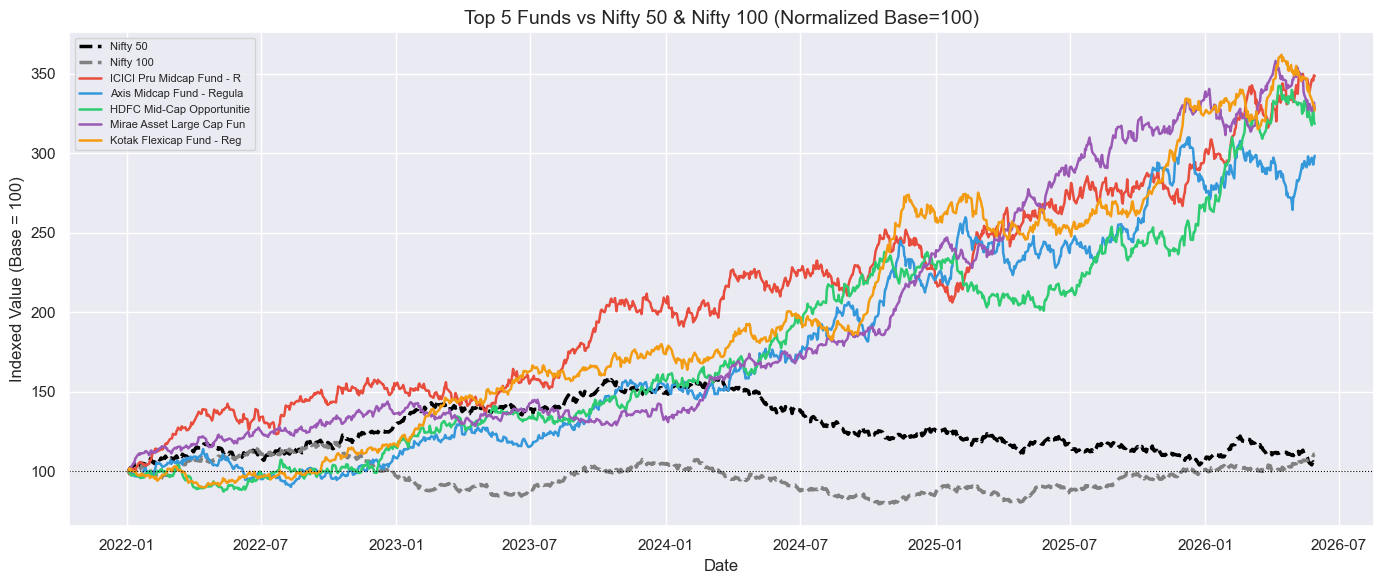

Benchmark comparison chart saved


In [10]:
# Top 5 funds by composite score
top5_codes = df_score.head(5)["amfi_code"].tolist()
top5_names = df_score.head(5).set_index("amfi_code")["scheme_name"].str[:25].to_dict()

nifty50  = df_bm[df_bm["index_name"] == "NIFTY50"].sort_values("date")
nifty100 = df_bm[df_bm["index_name"] == "NIFTY100"].sort_values("date")

fig, ax = plt.subplots(figsize=(14, 6))

# Normalize benchmarks to 100
ax.plot(nifty50["date"],
        nifty50["close_value"] / nifty50["close_value"].iloc[0] * 100,
        label="Nifty 50", linewidth=2.5,
        color="black", linestyle="--")
ax.plot(nifty100["date"],
        nifty100["close_value"] / nifty100["close_value"].iloc[0] * 100,
        label="Nifty 100", linewidth=2.5,
        color="gray", linestyle="--")

# Plot top 5 funds
colors = ["#e74c3c","#3498db","#2ecc71","#9b59b6","#f39c12"]
for code, color in zip(top5_codes, colors):
    grp = df_nav[df_nav["amfi_code"] == code].sort_values("date")
    normalized = grp["nav"] / grp["nav"].iloc[0] * 100
    ax.plot(grp["date"], normalized,
            label=top5_names[code],
            linewidth=1.8, color=color)

ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 (Normalized Base=100)",
             fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Value (Base = 100)")
ax.legend(fontsize=8)
ax.axhline(y=100, color="black", linewidth=0.8, linestyle=":")
plt.tight_layout()
plt.savefig("bluestock/reports/charts/benchmark_comparison.png", dpi=150)
plt.show()
print("Benchmark comparison chart saved")

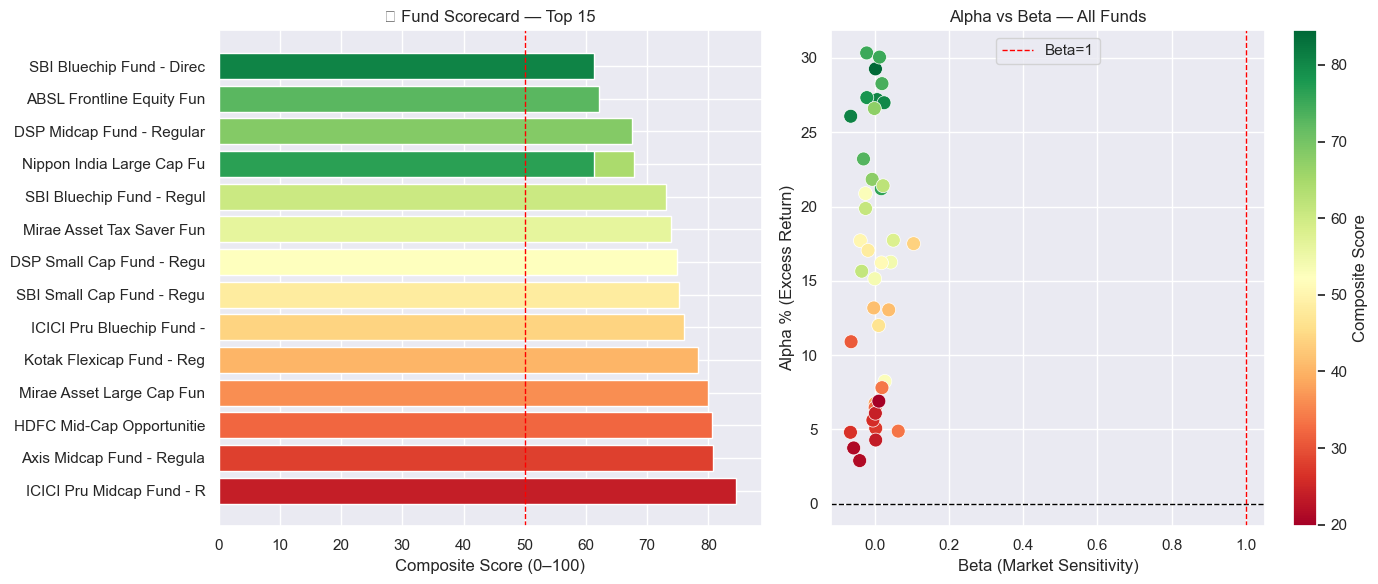

Scorecard chart saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 by composite score
top15 = df_score.head(15)

# Chart — Composite Score Bar
axes[0].barh(
    top15["scheme_name"].str[:25],
    top15["composite_score"],
    color=sns.color_palette("RdYlGn", 15)
)
axes[0].set_title("🏆 Fund Scorecard — Top 15")
axes[0].set_xlabel("Composite Score (0–100)")
axes[0].axvline(x=50, color="red", linestyle="--", linewidth=1)

# Chart — Alpha vs Beta Scatter
scatter = axes[1].scatter(
    df_score["beta"],
    df_score["alpha_pct"],
    c=df_score["composite_score"],
    s=100, cmap="RdYlGn",
    edgecolors="white", linewidths=0.5
)
plt.colorbar(scatter, ax=axes[1], label="Composite Score")
axes[1].axhline(y=0,   color="black", linestyle="--", linewidth=1)
axes[1].axvline(x=1.0, color="red",   linestyle="--", linewidth=1, label="Beta=1")
axes[1].set_title("Alpha vs Beta — All Funds")
axes[1].set_xlabel("Beta (Market Sensitivity)")
axes[1].set_ylabel("Alpha % (Excess Return)")
axes[1].legend()

plt.tight_layout()
plt.savefig("bluestock/reports/charts/scorecard_alpha_beta.png", dpi=150)
plt.show()
print("Scorecard chart saved")

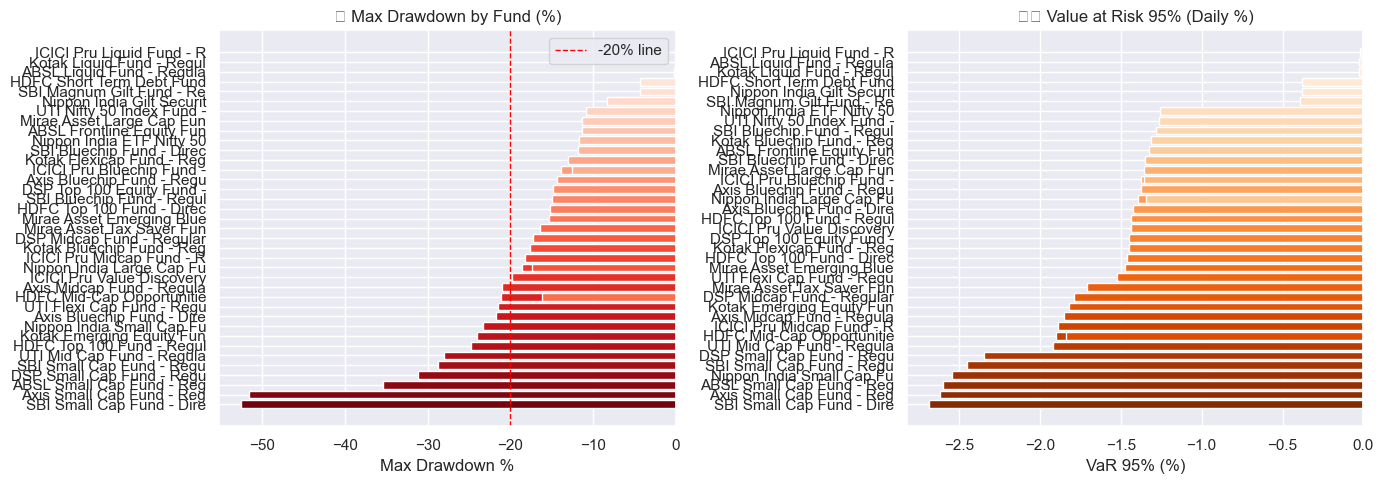

 Drawdown & VaR chart saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Max Drawdown Bar
dd_sorted = df_dd.sort_values("max_drawdown_pct")
axes[0].barh(
    dd_sorted["scheme_name"].str[:25],
    dd_sorted["max_drawdown_pct"],
    color=sns.color_palette("Reds_r", len(dd_sorted))
)
axes[0].set_title("📉 Max Drawdown by Fund (%)")
axes[0].set_xlabel("Max Drawdown %")
axes[0].axvline(x=-20, color="red",
                linestyle="--", linewidth=1, label="-20% line")
axes[0].legend()

# VaR Chart
var_sorted = df_var.sort_values("var_95_pct")
axes[1].barh(
    var_sorted["scheme_name"].str[:25],
    var_sorted["var_95_pct"],
    color=sns.color_palette("Oranges_r", len(var_sorted))
)
axes[1].set_title("⚠️ Value at Risk 95% (Daily %)")
axes[1].set_xlabel("VaR 95% (%)")

plt.tight_layout()
plt.savefig("bluestock/reports/charts/drawdown_var.png", dpi=150)
plt.show()
print(" Drawdown & VaR chart saved")

In [14]:
# Merge all metrics into one master table
df_master = df_cagr[["amfi_code","scheme_name","fund_house",
                      "category","sub_category",
                      "cagr_1y_pct","cagr_3y_pct","cagr_5y_pct"]].copy()

df_master = df_master.merge(
    df_sharpe[["amfi_code","sharpe_ratio","sortino_ratio","ann_std_pct"]],
    on="amfi_code", how="left")
df_master = df_master.merge(
    df_alpha[["amfi_code","alpha_pct","beta","r_squared"]],
    on="amfi_code", how="left")
df_master = df_master.merge(
    df_dd[["amfi_code","max_drawdown_pct"]],
    on="amfi_code", how="left")
df_master = df_master.merge(
    df_var[["amfi_code","var_95_pct","cvar_95_pct"]],
    on="amfi_code", how="left")
df_master = df_master.merge(
    df_score[["amfi_code","composite_score"]],
    on="amfi_code", how="left")

df_master.to_csv(f"{PROC}/performance_master.csv", index=False)

print( "Master metrics table saved")
print(f"   Shape : {df_master.shape}")
print(f"\nC olumns : {df_master.columns.tolist()}")
print(f"\n{df_master.head(3).to_string(index=False)}")

Master metrics table saved
   Shape : (40, 18)

C olumns : ['amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category', 'cagr_1y_pct', 'cagr_3y_pct', 'cagr_5y_pct', 'sharpe_ratio', 'sortino_ratio', 'ann_std_pct', 'alpha_pct', 'beta', 'r_squared', 'max_drawdown_pct', 'var_95_pct', 'cvar_95_pct', 'composite_score']

 amfi_code                                        scheme_name       fund_house category   sub_category  cagr_1y_pct  cagr_3y_pct  cagr_5y_pct  sharpe_ratio  sortino_ratio  ann_std_pct  alpha_pct    beta  r_squared  max_drawdown_pct  var_95_pct  cvar_95_pct  composite_score
    100016          HDFC Top 100 Fund - Regular Plan - Growth HDFC Mutual Fund   Equity      Large Cap        -2.22         1.29         2.32        -0.202         -0.351       14.548     3.7476 -0.0583     0.0027            -24.73     -1.4364      -1.8060            21.12
    100025       HDFC Short Term Debt Fund - Regular - Growth HDFC Mutual Fund     Debt Short Duration         3.70         3.

In [15]:
files = [
    "returns_computed.csv",
    "sharpe_sortino.csv",
    "alpha_beta.csv",
    "max_drawdown.csv",
    "var_cvar.csv",
    "fund_scorecard.csv",
    "performance_master.csv",
]

print("="*50)
print("DAY 4 OUTPUT FILES")
print("="*50)
for f in files:
    path = f"bluestock/data/processed/{f}"
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"{f:<35} {len(df):>5} rows")
    else:
        print(f" MISSING — {f}")

charts = [
    "benchmark_comparison.png",
    "scorecard_alpha_beta.png",
    "drawdown_var.png",
]
print()
for c in charts:
    path = f"bluestock/reports/charts/{c}"
    status = "" if os.path.exists(path) else "❌"
    print(f"{status} {c}")

DAY 4 OUTPUT FILES
returns_computed.csv                   40 rows
sharpe_sortino.csv                     40 rows
alpha_beta.csv                         40 rows
max_drawdown.csv                       40 rows
var_cvar.csv                           40 rows
fund_scorecard.csv                     40 rows
performance_master.csv                 40 rows

 benchmark_comparison.png
 scorecard_alpha_beta.png
 drawdown_var.png


In [16]:
import subprocess

cmds = [
    ["git", "-C", "bluestock", "add", "."],
    ["git", "-C", "bluestock", "commit", "-m",
     "Day 4: Performance analytics — CAGR, Sharpe, Alpha, Beta, VaR, Scorecard"],
    ["git", "-C", "bluestock", "push", "origin", "main"],
]

for cmd in cmds:
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout or r.stderr)


[main 6e1e056] Day 4: Performance analytics â€” CAGR, Sharpe, Alpha, Beta, VaR, Scorecard
 10 files changed, 287 insertions(+)
 create mode 100644 data/processed/alpha_beta.csv
 create mode 100644 data/processed/fund_scorecard.csv
 create mode 100644 data/processed/max_drawdown.csv
 create mode 100644 data/processed/performance_master.csv
 create mode 100644 data/processed/returns_computed.csv
 create mode 100644 data/processed/sharpe_sortino.csv
 create mode 100644 data/processed/var_cvar.csv
 create mode 100644 reports/charts/benchmark_comparison.png
 create mode 100644 reports/charts/drawdown_var.png
 create mode 100644 reports/charts/scorecard_alpha_beta.png

To https://github.com/gauravhkulkarni24-ship-it/MutualFund_capstone.git
   1c8a9a6..6e1e056  main -> main

